In [123]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.ticker import FormatStrFormatter

import seaborn as sns
from pathlib import Path
import re
import json

In [124]:
# read all results.json files from outputs
all_results = list(Path("../outputs").glob("**/results.json"))
datasets_name = ["gigaspeech","spgispeech_2"]
filtered_results = [result for result in all_results if any(dataset in str(result) for dataset in datasets_name)]
all_train_logs = list(Path("../outputs").glob("**/*.log"))
filtered_train_logs = [log for log in all_train_logs if any(dataset in str(log) for dataset in datasets_name)]


In [ ]:
metadata = {
    "000": {"Lora Rank": 0,"type": "base"},
    "001": {"lora_rank": 0,"type": "standard"},
    "002": {"lora_rank": 8,"type": "lora"},
    "0021": {"lora_rank": 16,"type": "lora"},
    "0022": {"lora_rank": 32,"type": "lora"},
    "0023": {"lora_rank": 64,"type": "lora"},
    "0024": {"lora_rank": 128,"type": "lora"},
    "0025": {"lora_rank": 256,"type": "lora"},
    "0026": {"lora_rank": 512,"type": "lora"},
    "0027": {"lora_rank": 96,"type": "lora"},
}

In [ ]:
# metdadata to dataframe 
df_metadata = pd.DataFrame.from_dict(metadata,orient='index').reset_index()
df_metadata.columns = ['run_name','Lora Rank','type']
gigaspeech_logs = [log for log in all_train_logs if "gigaspeech" in str(log)]
gigaspeech_dict = {}
for log in gigaspeech_logs:
    run_name = str(log).split("/")[3]
    trainable_parameters = 0
    
    with open(log, "r") as f:
        for line in f:
            # Case-insensitive check
            if "trainable params" in line.lower():
                match = re.search(r"trainable params:\s*([\d,]+)", line, re.IGNORECASE)
                if match:
                    # Remove commas and convert to int
                    trainable_parameters = int(match.group(1).replace(",", ""))
                    break
    
    gigaspeech_dict[run_name] = {
        "all_parameters": 816967680, 
        "trainable_parameters": trainable_parameters
    }
df_gigaspeech = pd.DataFrame.from_dict(gigaspeech_dict,orient='index').reset_index()
df_gigaspeech.columns = ['run_name','all_parameters','Trainable Parameters']

df_metadata = pd.merge(df_metadata,df_gigaspeech,on='run_name')
df_metadata['Trainable Parameters (%)'] = df_metadata['Trainable Parameters'].astype(int)/df_metadata['all_parameters'].astype(int)*100
df_metadata

,run_name,Lora Rank,Type,all_parameters,Trainable Parameters,Trainable Parameters (%)
0,000,0,base,816967680,0,0.000000
1,001,0,standard,816967680,53109760,6.500840
2,002,8,lora,816967680,423112,0.051791
3,0021,16,lora,816967680,846224,0.103581
4,0022,32,lora,816967680,1692448,0.207162
5,0023,64,lora,816967680,3384896,0.414324
6,0024,128,lora,816967680,6769792,0.828649
7,0025,256,lora,816967680,13539584,1.657297
8,0026,512,lora,816967680,27079168,3.314595
9,0027,96,lora,816967680,5077344,0.621487


In [127]:
# reading wer from results.json into a results dictionary incuding run_name and wer
gigaspeech_results = [res for res in all_results if "gigaspeech" in str(res)]
results_dict = {}
for res in gigaspeech_results:
    run_name = str(res).split("/")[3]
    with open(res) as f:
        data = json.load(f)
    wer = data['metrics']['wer']
    results_dict[run_name] = {"wer":wer}
df_gigaspeech_results = pd.DataFrame.from_dict(results_dict,orient='index').reset_index()
df_gigaspeech_results.columns = ['run_name','wer']
df_gigaspeech_results['Dataset'] = 'GigaSpeech'
df_gigaspeech_results

,run_name,wer,Dataset
0,0022,0.145282,GigaSpeech
1,0027_r1,0.144148,GigaSpeech
2,0023,0.130334,GigaSpeech
3,0027_r,0.153482,GigaSpeech
4,0021,0.160483,GigaSpeech
5,000,0.149531,GigaSpeech
6,0027_r3,0.142262,GigaSpeech
7,0024,0.133787,GigaSpeech
8,0027_r2,0.140749,GigaSpeech
9,0027,0.148622,GigaSpeech


In [128]:
df_total_gigaspeech = pd.merge(df_metadata,df_gigaspeech_results, on="run_name", how="inner")
df_total_gigaspeech

,run_name,Lora Rank,Type,all_parameters,Trainable Parameters,Trainable Parameters (%),wer,Dataset
0,000,0,base,816967680,0,0.000000,0.149531,GigaSpeech
1,001,0,standard,816967680,53109760,6.500840,0.135231,GigaSpeech
2,002,8,lora,816967680,423112,0.051791,0.166650,GigaSpeech
3,0021,16,lora,816967680,846224,0.103581,0.160483,GigaSpeech
4,0022,32,lora,816967680,1692448,0.207162,0.145282,GigaSpeech
5,0023,64,lora,816967680,3384896,0.414324,0.130334,GigaSpeech
6,0024,128,lora,816967680,6769792,0.828649,0.133787,GigaSpeech
7,0025,256,lora,816967680,13539584,1.657297,0.135291,GigaSpeech
8,0026,512,lora,816967680,27079168,3.314595,0.167381,GigaSpeech
9,0027,96,lora,816967680,5077344,0.621487,0.148622,GigaSpeech


In [129]:
spgispeech_2_results = [res for res in all_results if "spgispeech_2" in str(res)]
results_dict = {}
for res in spgispeech_2_results:
    run_name = str(res).split("/")[3]
    with open(res) as f:
        data = json.load(f)
    wer = data['metrics']['wer']
    results_dict[run_name] = {"wer":wer}
df_spgispeech_results = pd.DataFrame.from_dict(results_dict,orient='index').reset_index()
df_spgispeech_results.columns = ['run_name','wer']
df_spgispeech_results['Dataset'] = 'SPGISpeech_2'
df_total_spgispeech = pd.merge(df_metadata,df_spgispeech_results, on="run_name", how="inner")
df_total_spgispeech

,run_name,Lora Rank,Type,all_parameters,Trainable Parameters,Trainable Parameters (%),wer,Dataset
0,000,0,base,816967680,0,0.000000,0.115615,SPGISpeech_2
1,001,0,standard,816967680,53109760,6.500840,0.068312,SPGISpeech_2
2,002,8,lora,816967680,423112,0.051791,0.079877,SPGISpeech_2
3,0021,16,lora,816967680,846224,0.103581,0.075773,SPGISpeech_2
4,0022,32,lora,816967680,1692448,0.207162,0.071233,SPGISpeech_2
5,0023,64,lora,816967680,3384896,0.414324,0.068598,SPGISpeech_2
6,0024,128,lora,816967680,6769792,0.828649,0.071936,SPGISpeech_2
7,0026,512,lora,816967680,27079168,3.314595,0.076543,SPGISpeech_2
8,0027,96,lora,816967680,5077344,0.621487,0.069845,SPGISpeech_2


In [130]:
df_total = pd.concat([df_total_gigaspeech, df_total_spgispeech],ignore_index=True)
df_total['WER (%)'] = df_total['wer']*100
df_total

,run_name,Lora Rank,Type,all_parameters,Trainable Parameters,Trainable Parameters (%),wer,Dataset,WER (%)
0,000,0,base,816967680,0,0.000000,0.149531,GigaSpeech,14.953090
1,001,0,standard,816967680,53109760,6.500840,0.135231,GigaSpeech,13.523135
2,002,8,lora,816967680,423112,0.051791,0.166650,GigaSpeech,16.664974
3,0021,16,lora,816967680,846224,0.103581,0.160483,GigaSpeech,16.048349
4,0022,32,lora,816967680,1692448,0.207162,0.145282,GigaSpeech,14.528216
5,0023,64,lora,816967680,3384896,0.414324,0.130334,GigaSpeech,13.033353
6,0024,128,lora,816967680,6769792,0.828649,0.133787,GigaSpeech,13.378703
7,0025,256,lora,816967680,13539584,1.657297,0.135291,GigaSpeech,13.529081
8,0026,512,lora,816967680,27079168,3.314595,0.167381,GigaSpeech,16.738057
9,0027,96,lora,816967680,5077344,0.621487,0.148622,GigaSpeech,14.862170


In [ ]:
def plot_results(df, ax=None, title="WER (%) vs LoRA Rank", add_legend=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    x_col_name = 'Lora Rank' 
    label_col_name = 'Trainable Parameters (%)'
    line_data = df[df[x_col_name] > 0].sort_values(by=x_col_name)
    baseline_data = df[df[x_col_name] == 0]
    # 1. Plot Line
    line_handle, = ax.plot(
        line_data[x_col_name], 
        line_data['WER (%)'], 
        linestyle='-', 
        alpha=0.7, 
        color='tab:blue',
        label='LoRA Model'
    )
    # 2. Scatter Points
    scale_factor = 300
    ax.scatter(
        line_data[x_col_name], 
        line_data['WER (%)'], 
        s=line_data[label_col_name] * scale_factor, 
        color='tab:blue',
        alpha=1.0,
        zorder=5
    )
    # 3. Baselines
    baseline_handles = []
    colors = ['red', 'green', 'orange', 'purple']
    for i, (idx, row) in enumerate(baseline_data.iterrows()):
        label_text = f"{row['type']}" # Simplified label for shared legend
        h = ax.axhline(
            y=row['WER (%)'], 
            color=colors[i % len(colors)], 
            linestyle='--', 
            label=label_text
        )
        baseline_handles.append(h)
    # --- AXES SETTINGS ---
    ax.set_xscale('log') 
    ax.set_xlabel('LoRA Rank (r)') 
    ax.set_ylabel('WER (%)')
    ax.set_title(title)
    ax.grid(True, which="both", linestyle='--', alpha=0.5)
    
    ax.set_xticks(sorted(line_data[x_col_name].unique()))
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    # --- HANDLE COLLECTION ---
    size_description_handle = mlines.Line2D(
        [], [], 
        color='tab:blue', 
        marker='o', 
        linestyle='None',
        markersize=10, 
        label='∝ #Trainable Params'
    )
    all_handles = [line_handle] + baseline_handles + [size_description_handle]
    all_labels = [h.get_label() for h in all_handles]
    if add_legend:
        ax.legend(all_handles, all_labels, loc='best')
    return all_handles, all_labels

In [132]:
df_g = df_total[df_total['Dataset'] == "GigaSpeech"]
df_s = df_total[df_total['Dataset'] == "SPGISpeech_2"]

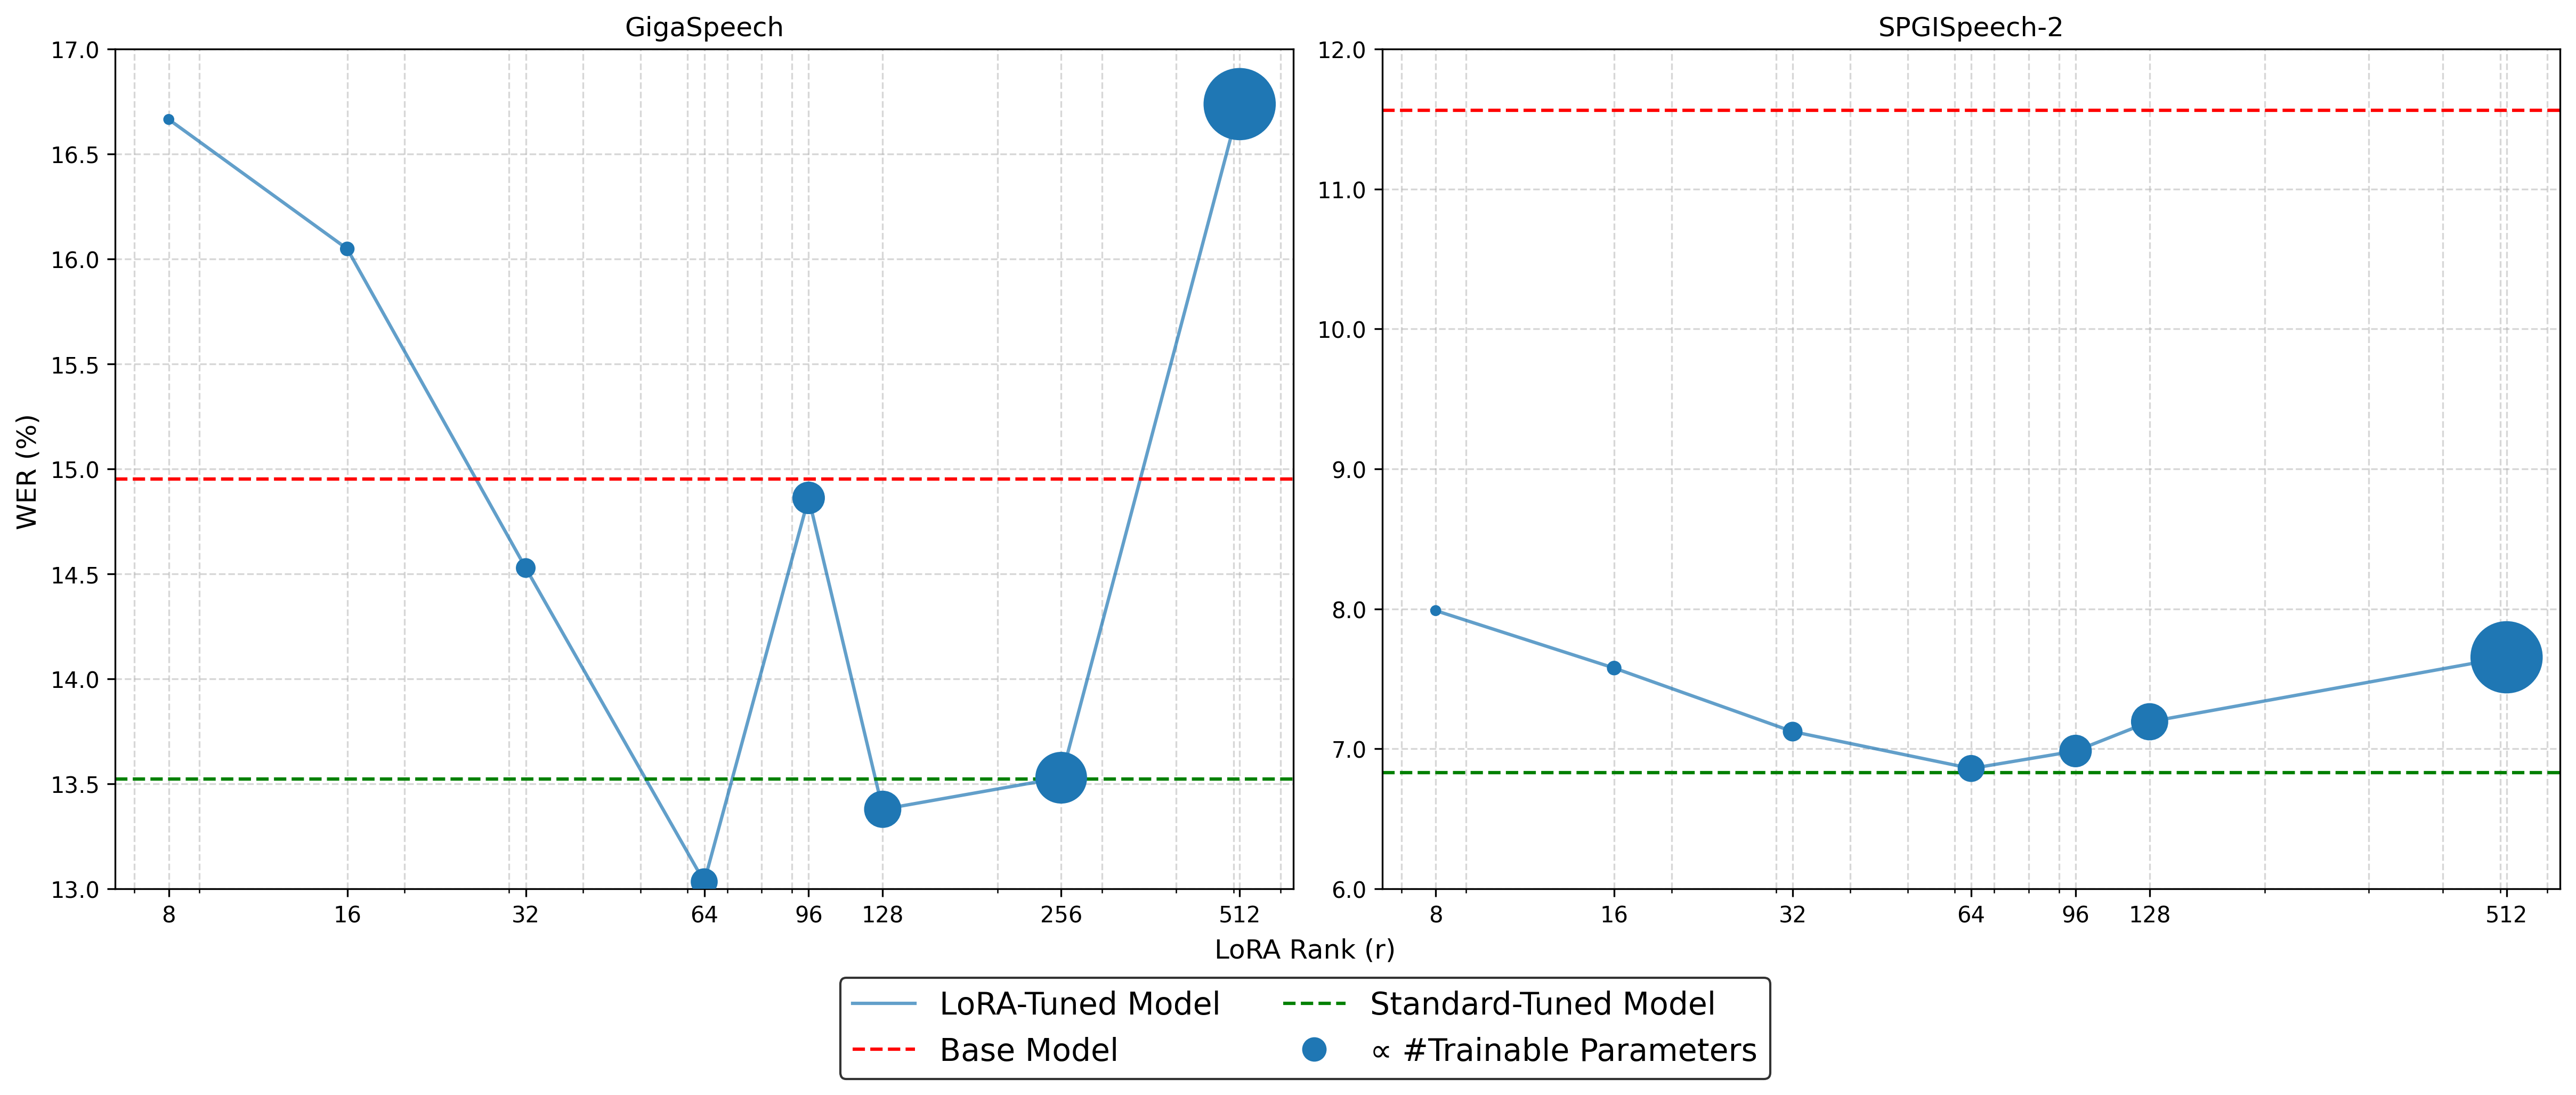

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6),dpi=300)
# 1. Plot first dataset (don't add local legend, but capture the handles)
handles, labels = plot_results(df_g, ax=axes[0], title="GigaSpeech", add_legend=False)
labels = ['LoRA-Tuned Model', 'Base Model', 'Standard-Tuned Model', '∝ #Trainable Parameters']
# 2. Plot second dataset (don't add local legend)
# We assume the legend entries (colors/types) are similar enough to share
plot_results(df_s, ax=axes[1], title="SPGISpeech-2", add_legend=False)
# 3. Create ONE Global Legend on the Figure
# bbox_to_anchor centers it at bottom of figure
fig.legend(
    handles, 
    labels, 
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=True,         # Turns the border on
    edgecolor='black',    # Sets the border color to black
    fancybox=True,
    fontsize=14,       # Rounded corners (False for partial square)
)
axes[0].set_ylim(13.0, 17.0)
axes[1].set_ylim(6.0, 12.0)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
# --- ADD GLOBAL LABELS ---
# valign='center' aligns it vertically in the middle height
fig.text(0.5, 0.0001, 'LoRA Rank (r)', ha='center', va='center', fontsize=12)
# rotation='vertical' makes it standard Y-axis label style
fig.text(0.001, 0.5, 'WER (%)', ha='center', va='center', rotation='vertical', fontsize=12)
# Adjust layout to make room for these new outer labels
plt.subplots_adjust(bottom=0.15, left=0.12)
plt.tight_layout()
plt.show()

### Recacluating WER with normalisation

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import evaluate
from whisper_normalizer.english import EnglishTextNormalizer
from tqdm.notebook import tqdm

In [135]:
def calculate_wer_filtered(json_file_path):
    # Initialize the normalizer
    normalizer = EnglishTextNormalizer()
    
    # Load the WER metric
    wer_metric = evaluate.load("wer")
    # Read the predictions file
    print(f"Reading from {json_file_path}...")
    with open(json_file_path, 'r') as f:
        data = json.load(f)
    predictions = data['predictions']
    references = data['references']
    # 1. Normalize
    print("Normalizing text...")
    predictions_norm = [normalizer(p) for p in predictions]
    references_norm = [normalizer(r) for r in references]
    # 2. Filter out empty references
    # We must filter pairs to keep predictions aligned with references
    final_preds = []
    final_refs = []
    lines_dropped = 0
    for p, r in zip(predictions_norm, references_norm):
        if len(r.strip()) > 0:
            final_preds.append(p)
            final_refs.append(r)
        else:
            lines_dropped += 1
    print(f"Dropped {lines_dropped} examples where reference became empty after normalization.")
    print(f"Remaining examples: {len(final_refs)}")
    # 3. Calculate WER
    if len(final_refs) == 0:
        print("No valid references left to calculate WER.")
        return None
    print("Calculating WER...")
    wer = wer_metric.compute(predictions=final_preds, references=final_refs)
    print(f"WER: {wer * 100:.2f}%")
    return wer

In [136]:
calculate_wer_filtered("/mnt/asr-data-scaling/outputs/gigaspeech/001/gigaspeech-001_frac_1.0_subset_0/predictions.json")

Reading from /mnt/asr-data-scaling/outputs/gigaspeech/001/gigaspeech-001_frac_1.0_subset_0/predictions.json...
Normalizing text...
Dropped 0 examples where reference became empty after normalization.
Remaining examples: 19898
Calculating WER...
WER: 13.39%


0.13394944911223844

In [137]:
with open("/mnt/asr-data-scaling/outputs/gigaspeech/001/gigaspeech-001_frac_1.0_subset_0/predictions.json","r") as f:
    data = json.load(f)
for i,r in enumerate(data["predictions"]):
    if len(r.strip()) == 0:
        print(i)
    

2682
3506
3866
9772
11113
11391
14181
15890
17441
17759


In [138]:
data['references'][11113]

'bela karolyis hear him'

In [139]:
all_preds = list(Path("/mnt/asr-data-scaling/outputs/gigaspeech").glob("**/predictions.json"))

In [140]:
new_wers =[]
for p in tqdm(all_preds):
    exp_id = str(p).split("/")[-3]
    wer = calculate_wer_filtered(p)
    new_wers.append({"exp_id": exp_id, "wer": wer})
new_wers

  0%|          | 0/39 [00:00<?, ?it/s]

Reading from /mnt/asr-data-scaling/outputs/gigaspeech/0022/gigaspeech-0022_frac_1.0_subset_0/predictions.json...
Normalizing text...
Dropped 0 examples where reference became empty after normalization.
Remaining examples: 19898
Calculating WER...
WER: 13.94%
Reading from /mnt/asr-data-scaling/outputs/gigaspeech/0022/seed_123_frac_1.0_subset_0/predictions.json...
Normalizing text...
Dropped 0 examples where reference became empty after normalization.
Remaining examples: 19898
Calculating WER...
WER: 14.11%
Reading from /mnt/asr-data-scaling/outputs/gigaspeech/0022/seed_123456_frac_1.0_subset_0/predictions.json...
Normalizing text...


/root/.cache/pypoetry/virtualenvs/asr-data-scaling-hl6LQY1z-py3.12/lib/python3.12/site-packages/whisper_normalizer/basic.py:90: SyntaxWarning: invalid escape sequence '\X'
  """


KeyboardInterrupt: 

In [ ]:
df_wer_new = pd.DataFrame(new_wers)
df_wer_new.sort_values(by="wer", inplace=True)
df_wer_new = df_wer_new.rename(columns = {"exp_id":"run_name"})
df_total_new = pd.merge(df_wer_new, df_metadata, on="run_name", how="outer")
df_total_new = df_total_new.rename(columns = {"wer":"WER (%)"})

([<matplotlib.lines.Line2D at 0x74f476c25be0>,
 ['LoRA Model', 'base', 'standard', '∝ #Trainable Params'])

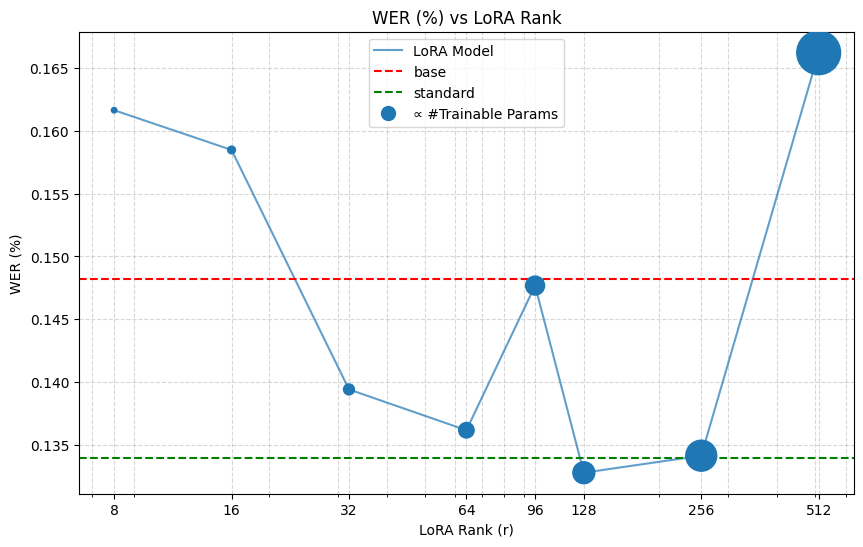

In [ ]:
plot_results(df_total_new)

## Diagnose the rank=96 issue

In [ ]:
import pandas as pd
import evaluate
from tqdm.notebook import tqdm  
import json

In [ ]:
wer_metric = evaluate.load("wer")
tqdm.pandas()

In [ ]:
r_64_preds_path = "/mnt/asr-data-scaling/outputs/gigaspeech/0023/gigaspeech-0023_frac_1.0_subset_0/predictions.json"
r_96_preds_path = "/mnt/asr-data-scaling/outputs/gigaspeech/0027/gigaspeech-0027_frac_1.0_subset_0/predictions.json"

r_64_preds = json.load(open(r_64_preds_path))
r_96_preds = json.load(open(r_96_preds_path))

In [ ]:
df_64.columns

Index(['ID', '64', 'references'], dtype='object')

In [ ]:
df_64 = pd.DataFrame(r_64_preds).reset_index()
df_64.rename(columns={"predictions": "64","index": "ID"}, inplace=True)
df_64["wer_64"] = df_64.progress_apply(lambda x: wer_metric.compute(predictions=[x["64"]], references=[x["references"]]), axis=1)
df_96 = pd.DataFrame(r_96_preds).reset_index()
df_96.rename(columns={"predictions": "96","index": "ID"}, inplace=True)
df_96["wer_96"] = df_96.progress_apply(lambda x: wer_metric.compute(predictions=[x["96"]], references=[x["references"]]), axis=1)
df_total = pd.merge(df_64, df_96,on='ID', how="inner")
df_total.tail()

  0%|          | 0/19898 [00:00<?, ?it/s]

  0%|          | 0/19898 [00:00<?, ?it/s]

,ID,64,references_x,wer_64,96,references_y,wer_96
19893,19893,it was a very difficult experience,it was it was a a very difficult experience,0.333333,it was a very difficult experience,it was it was a a very difficult experience,0.333333
19894,19894,i would say will get attention this time,you know i would say is ah will get attention ...,0.333333,i would say will get attention this time,you know i would say is ah will get attention ...,0.333333
19895,19895,is a very and it just pisses me off that peopl...,is a very and and it just pisses me off that p...,0.317073,is a very and it just pisses me off that peopl...,is a very and and it just pisses me off that p...,0.317073
19896,19896,6 foot one big unit of a defender,6 foot one big unit of a defender,0.000000,6 foot one big unit of a defender,6 foot one big unit of a defender,0.000000
19897,19897,okay what did you love most about the town whe...,okay what did you love most about the town whe...,0.000000,okay what did you love most about the town whe...,okay what did you love most about the town whe...,0.000000


In [ ]:
df_diff = df_total[df_total["wer_96"]!=df_total["wer_64"]].sort_values("wer_96",ascending=False).reset_index(drop=True)
df_diff

,ID,64,references_x,wer_64,96,references_y,wer_96
0,15485,box,books,1.000000,knox knox knox knox knox knox knox knox knox k...,books,222.0
1,1939,shame,hey,1.000000,shame shame shame shame shame shame shame sham...,hey,222.0
2,114,outside outside,outside,1.000000,outside outside outside outside outside outsid...,outside,221.0
3,9671,2,2,0.000000,oopsie oopsie oopsie oopsie oopsie oopsie oops...,2,124.0
4,13537,and i,and i,0.000000,aye aye aye aye aye aye aye aye aye aye aye ay...,and i,111.0
...,...,...,...,...,...,...,...
3557,17422,the far more effective method will always be t...,the far more effective method will always be t...,0.046512,the far more effective method will always be t...,the far more effective method will always be t...,0.0
3558,17413,we got new strategy,me got new strategy,0.250000,me got new strategy,me got new strategy,0.0
3559,17387,and i want you to take a moment to appreciate ...,and i want you to take a moment to appreciate ...,0.047619,and i want you to take a moment to appreciate ...,and i want you to take a moment to appreciate ...,0.0
3560,17376,you really need to find somebody who is willin...,you really need to find somebody who is willin...,0.051282,you really need to find somebody who is willin...,you really need to find somebody who is willin...,0.0


In [ ]:
def count_words(text):
    return len(text.split())

In [ ]:
df_total["count_ref_words"] = df_total["references_x"].apply(lambda x: len(x.split()))
df_total_filtered = df_total[df_total["count_ref_words"] > 5].reset_index(drop=True)
print("mean wer 64:", df_total_filtered["wer_64"].mean())
print("mean wer 96:", df_total_filtered["wer_96"].mean())


mean wer 64: 0.13449995077207272
mean wer 96: 0.1461893194769634


### Experments with multiseed runs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

In [2]:
gigaspeech_002_dir = "../outputs/gigaspeech/002"
spgispeech_2_002_dir = "../outputs/spgispeech_2/002"
gigaspeech_002_results = list(Path(gigaspeech_002_dir).glob("**/results.json"))
spgispeech_2_002_results = list(Path(spgispeech_2_002_dir).glob("**/results.json"))
seeds = [42,123,1234,12345,123456]
results={"gigaspeech_m":{},"spgispeech_2":{}}
for seed in seeds:
    for p in gigaspeech_002_results:
        if f"{seed}_" in str(p):
            r = json.load(p.open())
            results["gigaspeech_m"][seed] = r["metrics"]["wer"]
    for p in spgispeech_2_002_results:
        if f"{seed}_" in str(p):
            r = json.load(p.open())
            results["spgispeech_2"][seed] = r["metrics"]["wer"]

results    


{'gigaspeech_m': {42: 0.16664973776721856,
  123: 0.1873285948930878,
  1234: 0.21589053856196844,
  12345: 0.21445860140864959,
  123456: 0.22308243052751275},
 'spgispeech_2': {42: 0.07987742827253765,
  123: 0.07812558973223219,
  1234: 0.07824665174518013,
  12345: 0.07934760393351845,
  123456: 0.07894596290232646}}

In [3]:
df = pd.DataFrame(results).T
df

,42,123,1234,12345,123456
gigaspeech_m,0.166650,0.187329,0.215891,0.214459,0.223082
spgispeech_2,0.079877,0.078126,0.078247,0.079348,0.078946


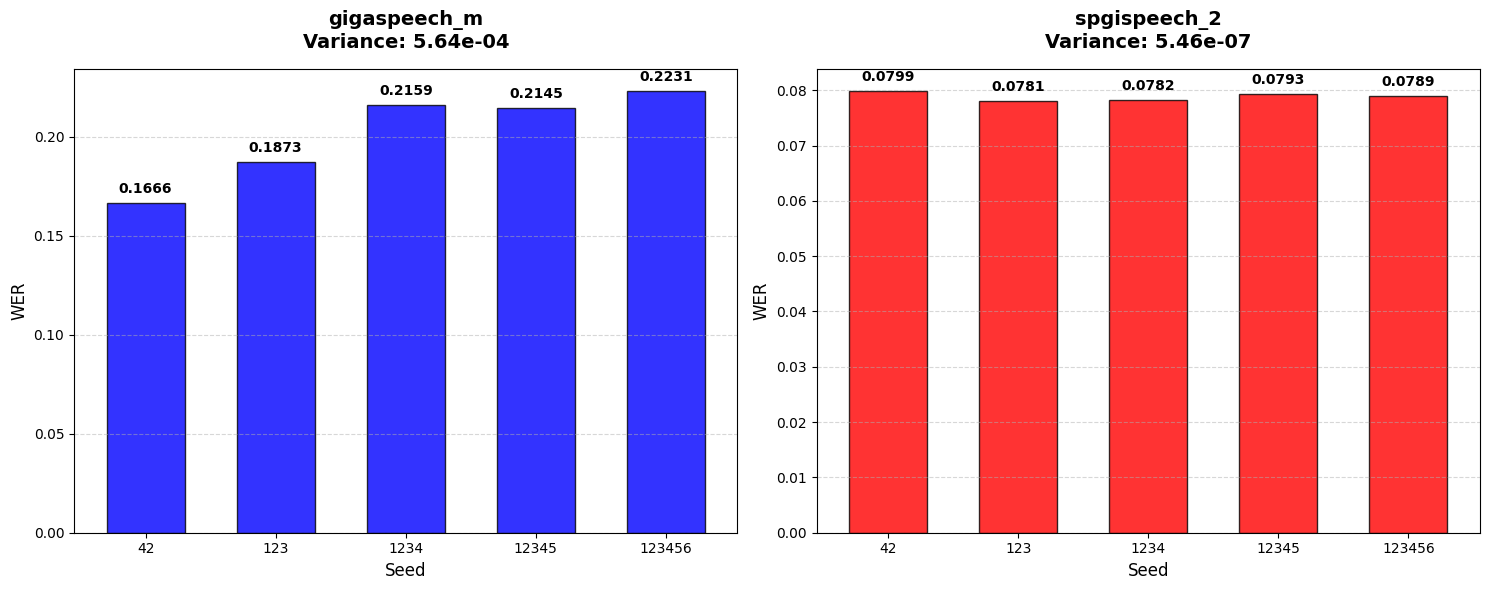

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
colors = ['blue', 'red']
for i, (dataset_name, row) in enumerate(df.iterrows()):
    ax = axes[i]
    
    # Plot bars
    row.plot(kind='bar', ax=ax, color=colors[i], edgecolor='black', alpha=0.8, width=0.6)
    
    # Calculate Variance
    variance = row.var()
    
    # Update title with Variance
    # Using scientific notation or 6 decimal places is usually best for these small values
    ax.set_title(f"{dataset_name}\nVariance: {variance:.2e}", fontsize=14, fontweight='bold', pad=15)
    
    ax.set_xlabel('Seed', fontsize=12)
    ax.set_ylabel('WER', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=0)
    
    # Add value labels
    for p in ax.patches:
        value = p.get_height()
        if pd.notna(value) and value > 0:
            ax.annotate(f'{value:.4f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', 
                        fontsize=10, fontweight='bold',
                        xytext=(0, 5), 
                        textcoords='offset points')
plt.tight_layout()
plt.show()

## Multiseeds Analysis

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import re
from matplotlib.ticker import ScalarFormatter


In [6]:
datasets = ["spgispeech_2", "gigaspeech"]
all_results_paths = list(Path("../outputs").glob("**/results.json"))
filtered_results_paths = [path for path in all_results_paths if any(dataset in str(path) for dataset in datasets)]
baselines = ['000','001']
filtered_results_paths_seeds = [path for path in filtered_results_paths if "seed" in str(path) or any(baseline in str(path) for baseline in baselines) and not "streaming" in str(path)]
dataset_dict = {name: {} for name in datasets}
for path in filtered_results_paths_seeds:
    for dataset in datasets:
        if dataset in str(path):
            exp_id_match = re.search(r'(?<=\/)\d+(?=\/)', str(path))
            exp_id ="NA"
            if exp_id_match:
                exp_id = exp_id_match.group()
            seed="NA"
            if "seed" in str(path):
                seed = re.search(r'(?<=seed_)[^/_]+', str(path)).group()
            r = json.load(path.open())
            wer =  r["metrics"]["wer"]
            dataset_dict[dataset].update({(exp_id, seed): wer})

df = pd.DataFrame(dataset_dict).reset_index().rename(columns={"level_0": "exp_id", "level_1": "seed"}) 
df = df[~(df.spgispeech_2.isna()) & ~(df.gigaspeech.isna())]


In [9]:
df

,exp_id,seed,spgispeech_2,gigaspeech
0,000,NA,0.115615,0.149531
1,001,NA,0.068312,0.135231
2,0022,123,0.072206,0.142032
3,0022,123456,0.071265,0.131587
4,0022,12345,0.070489,0.143243
5,0022,1234,0.072066,0.156725
6,0022,42,0.071233,0.145282
7,0023,123,0.068782,0.135098
8,0023,123456,0.067725,0.139559
9,0023,12345,0.068980,0.139758


In [ ]:
metadata = {
    "000": {"Lora Rank": 0,"type": "base"},
    "001": {"Lora Rank": 0,"type": "standard"},
    "0020": {"Lora Rank": 8,"type": "lora"},
    "0021": {"Lora Rank": 16,"type": "lora"},
    "0022": {"Lora Rank": 32,"type": "lora"},
    "0023": {"Lora Rank": 64,"type": "lora"},
    "0024": {"Lora Rank": 128,"type": "lora"},
    "0025": {"Lora Rank": 256,"type": "lora"},
    "0026": {"Lora Rank": 512,"type": "lora"},
    "0027": {"Lora Rank": 96,"type": "lora"},
}


In [11]:
# add metadata to the df
df_metadata = pd.DataFrame(metadata).T.reset_index().rename(columns={"index":"exp_id"})
df_total = pd.merge(df_metadata,df,on="exp_id")

# df_total = df_total[df_total['exp_id']!="0024"]
df_total.sort_values(by=['exp_id','Lora Rank','seed'], inplace=True)

df_melted = df_total.melt(
    id_vars=['exp_id', 'Lora Rank', 'type', 'seed'], # Columns to keep as they are
    value_vars=['spgispeech_2', 'gigaspeech'],       # Columns to unpivot
    var_name='dataset',                              # Name for the new "key" column
    value_name='wer'                                 # Name for the new "value" column
)

In [12]:
def aggregate_wer_stats(df):
    # Define Median Absolute Deviation (MAD)
    mad_func = lambda x: (x - x.median()).abs().median()

    # Group by the core identifiers
    # Use tuples in .agg() to extract the 'first' instance of metadata
    stats = df.groupby(['dataset', 'exp_id']).agg(
        lora_rank=('Lora Rank', 'first'),
        type=('type', 'first'),
        mean=('wer', 'mean'),
        median=('wer', 'median'),
        std=('wer', 'std'),
        mad=('wer', mad_func)
    ).reset_index()

    # Move metadata columns to the front if desired
    cols = ['exp_id','lora_rank', 'type', 'dataset' , 'mean', 'median', 'std', 'mad']
    return stats[cols]

In [13]:
agg_df = aggregate_wer_stats(df_melted)
agg_df

,exp_id,lora_rank,type,dataset,mean,median,std,mad
0,000,0,base,gigaspeech,0.149531,0.149531,NaN,0.000000
1,001,0,standard,gigaspeech,0.135231,0.135231,NaN,0.000000
2,002,8,lora,gigaspeech,0.201482,0.214459,0.023750,0.008624
3,0021,16,lora,gigaspeech,0.164746,0.151800,0.036152,0.008683
4,0022,32,lora,gigaspeech,0.143774,0.143243,0.008970,0.002039
5,0023,64,lora,gigaspeech,0.138069,0.139559,0.005711,0.004462
6,0024,128,lora,gigaspeech,0.138543,0.141829,0.008808,0.004930
7,0025,256,lora,gigaspeech,0.141703,0.142602,0.006462,0.006087
8,0026,512,lora,gigaspeech,0.160983,0.157637,0.006056,0.001593
9,000,0,base,spgispeech_2,0.115615,0.115615,NaN,0.000000


In [14]:
def plot_wer_performance(df, dataset_name, metric_type='mean', color='blue', padding_rate=.15, log_scale=True):
    # 1. Prepare LoRA Data
    df_copy = df.copy()
    metric_cols = ['mean', 'std', 'median', 'mad', 'lora_rank']
    df_copy[metric_cols] = df_copy[metric_cols].apply(pd.to_numeric, errors='coerce')

    subset = df_copy[(df_copy['dataset'] == dataset_name) & (df_copy['lora_rank'] > 0)]
    subset = subset.sort_values('lora_rank').dropna(subset=['lora_rank', 'mean'])
    
    x_labels = subset['lora_rank'].astype(int).astype(str)
    
    if metric_type == 'mean':
        y, err = subset['mean'], subset['std']
        metric_label, err_label = "Mean", "Std Dev"
    else:
        y, err = subset['median'], subset['mad']
        metric_label, err_label = "Median", "MAD"

    plt.figure(figsize=(7, 5))
    
    # 2. Plot LoRA results
    # We assign the line to a variable to manage legend handles if needed
    plt.plot(x_labels, y, marker='o', label=f'WER ({metric_label})', linewidth=2, color=color, zorder=3)
    
    # ADDED LABEL HERE: This makes it eligible for the legend
    plt.fill_between(x_labels, y - err, y + err, color=color, alpha=0.2, zorder=2, 
                     label=f'WER ({err_label})')

    # 3. Baselines
    base_data = df_copy[(df_copy['lora_rank'] == 0) & (df_copy['dataset'] == dataset_name)]
    base_val = base_data[base_data['type'].str.lower() == 'base'][metric_type].mean()
    std_val = base_data[base_data['type'].str.lower() == 'standard'][metric_type].mean()

    all_y_points = y.tolist()

    if pd.notna(base_val):
        plt.axhline(y=base_val, color='black', linestyle='--', alpha=0.7, 
                    label=f'Base ({base_val*100:.2f}%)', zorder=1)
        all_y_points.append(base_val)

    if pd.notna(std_val):
        plt.axhline(y=std_val, color='red', linestyle=':', alpha=0.7, 
                    label=f'Standard-Tuned ({std_val*100:.2f}%)', zorder=1)
        all_y_points.append(std_val)

    # 4. Scale and Smart Limits
    if log_scale:
        plt.yscale('log')
        # Logarithmic padding: Multiply/Divide instead of Add/Subtract
        y_min, y_max = min(all_y_points), max(all_y_points)
        # We use a power-based padding for log scales
        plt.ylim(y_min / (1 + padding_rate), y_max * (1 + padding_rate))
        
        # Fixing the 'get_xaxis' style error by using gca()
        ax = plt.gca()
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_minor_formatter(ScalarFormatter())
    else:
        # Linear padding
        y_min, y_max = min(all_y_points), max(all_y_points)
        padding = (y_max - y_min) * padding_rate if y_max != y_min else 2
        plt.ylim(y_min - padding, y_max + padding)

    # 5. Formatting
    plt.title(f"{dataset_name.title()}: {metric_label} WER for LoRA fine-tuning (Proj_out),\nAggregated over five independent seed initializations.", fontsize=11)
    plt.xlabel("LoRA Rank", fontweight='bold')
    plt.ylabel("WER (%)", fontweight='bold')
    plt.grid(True, which="both", linestyle='--', alpha=0.4)
    
    # The legend will now automatically include the fill_between label
    plt.legend(loc='best', fontsize='small')
    plt.tight_layout()
    plt.show()

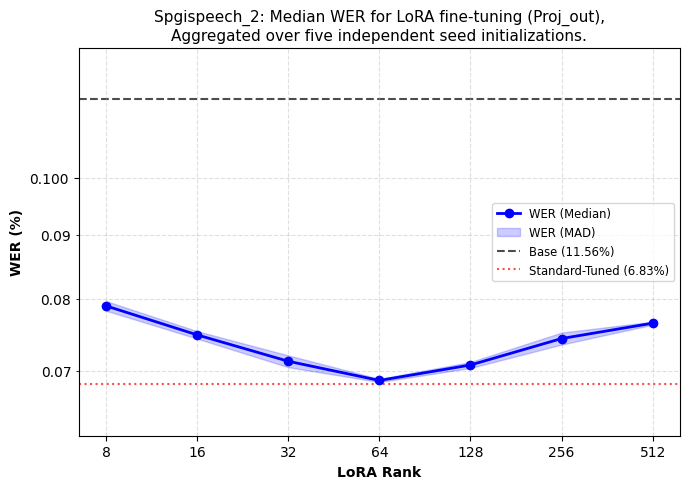

In [17]:
plot_wer_performance(agg_df,dataset_name='spgispeech_2',padding_rate=.10,log_scale=True,metric_type='median')

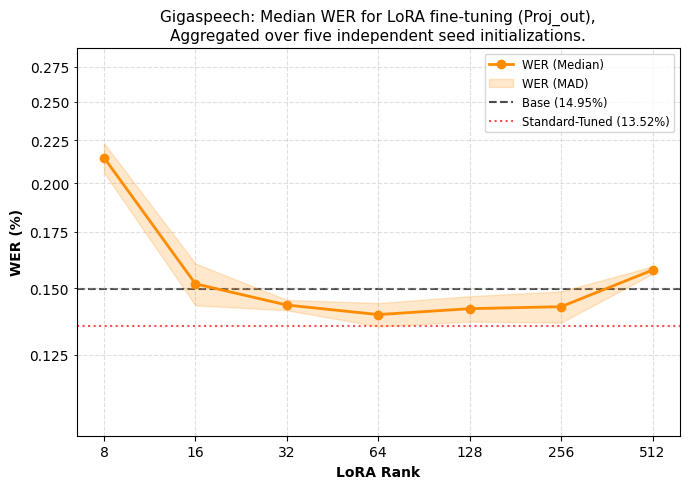

In [18]:
plot_wer_performance(agg_df,dataset_name='gigaspeech',color = 'darkorange',padding_rate=.35,log_scale=True,metric_type='median')

## Deeper Layers Training Results

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
import seaborn as sns
import numpy as np

In [25]:
spgi_paths = "/mnt/asr-data-scaling/outputs/spgispeech_2"
gigaspeech_paths = "/mnt/asr-data-scaling/outputs/gigaspeech"

In [ ]:
# def load_results(dir_to_results):
#     all_jsons = list(Path(dir_to_results).glob("**/results.json"))
#     all_jsons_filtered = [p for p in all_jsons if "002" not in str(p) or "0023" in str(p)]
    
#     results = []
#     exp_0023_wers = []
#     exp_0023_times = []
    
#     for p in all_jsons_filtered:
#         # Check if the path contains "0023" to catch the different seed results in that folder
#         is_0023 = "0023" in str(p)
#         is_vanilla = "000" in str(p)
        
#         with open(p, "r") as f:
#             data = json.load(f)
        
#         wer = data.get("metrics", {}).get("wer")
#         time = data.get("training_time")
        
#         if is_0023:
#             if wer is not None:
#                 exp_0023_wers.append(wer)
#             if time is not None:
#                 exp_0023_times.append(time)
#         elif is_vanilla:
#             if wer is not None:
#                 results.append({
#                     "id": "000",
#                     "wer": wer,
#                     "training_time": time
#                 })
#         else:
#             model_path = data.get("model_path", "")
#             parts = model_path.split("/")
#             run_id = parts[3] if len(parts) > 3 else model_path
#             results.append({
#                 "id": run_id,
#                 "wer": wer,
#                 "training_time": time
#             })
    
#     if exp_0023_wers:
#         results.append({
#             "id": "002",
#             "wer": sum(exp_0023_wers) / len(exp_0023_wers),
#             "training_time": sum(exp_0023_times) / len(exp_0023_times) if exp_0023_times else None
#         })
    
        
#     return results

In [27]:
def load_results(dir_to_results):
    all_jsons = list(Path(dir_to_results).glob("**/results.json"))
    # Filtering logic: exclude 002 variants unless they are 0023
    all_jsons_filtered = [p for p in all_jsons if "002" not in str(p) or "0023" in str(p)]
    
    # Group results by run_id to handle multiple seeds
    grouped_data = {}
    
    for p in all_jsons_filtered:
        with open(p, "r") as f:
            data = json.load(f)
        
        wer = data.get("metrics", {}).get("wer")
        time = data.get("training_time")
        
        if wer is None:
            continue
            
        # Determine the grouped run_id
        if "0023" in str(p):
            run_id = "002"
        elif "000" in str(p):
            run_id = "000"
        else:
            # Extract ID from model_path (e.g., '0071')
            model_path = data.get("model_path", "")
            parts = model_path.split("/")
            run_id = parts[3] if len(parts) > 3 else model_path
            
        if run_id not in grouped_data:
            grouped_data[run_id] = {"wers": [], "times": []}
            
        grouped_data[run_id]["wers"].append(wer)
        if time is not None:
            grouped_data[run_id]["times"].append(time)
            
    results = []
    for run_id, values in grouped_data.items():
        # Return the accumulated lists directly without aggregation
        results.append({
            "id": run_id,
            "wer": values["wers"],
            "training_time": values["times"]
        })
        
    return results

In [28]:
giga_speech_results = load_results(gigaspeech_paths)
giga_speech_results

[{'id': '0070', 'wer': [0.10247517025930945], 'training_time': [31424.8315]},
 {'id': '0071',
  'wer': [0.09553845048544651,
   0.09495378410450664,
   0.09463915431476357,
   0.09599181467066684,
   0.09595713107179753],
  'training_time': [32584.8806,
   32619.4445,
   32736.4644,
   32594.6107,
   33076.8733]},
 {'id': '0041', 'wer': [0.11092558138382605], 'training_time': []},
 {'id': '0040', 'wer': [0.10747208589641], 'training_time': []},
 {'id': '0061r', 'wer': [0.09724785642971988], 'training_time': [29462.8408]},
 {'id': '0060', 'wer': [0.09741879702414721], 'training_time': [28221.0341]},
 {'id': '0061', 'wer': [0.09606861406816318], 'training_time': [29465.0721]},
 {'id': '000', 'wer': [0.1495309043252925], 'training_time': []},
 {'id': '002',
  'wer': [0.13509757239581913,
   0.13955936965036456,
   0.1397575616439035,
   0.14559927065346379,
   0.13033353235112685],
  'training_time': []},
 {'id': '0080', 'wer': [0.10210356027142393], 'training_time': [31842.0337]},
 {'id'

In [29]:
giga_speech_df = pd.DataFrame(giga_speech_results)
giga_speech_df

,id,wer,training_time
0,0070,[0.10247517025930945],[31424.8315]
1,0071,"[0.09553845048544651, 0.09495378410450664, 0.0...","[32584.8806, 32619.4445, 32736.4644, 32594.610..."
2,0041,[0.11092558138382605],[]
3,0040,[0.10747208589641],[]
4,0061r,[0.09724785642971988],[29462.8408]
5,0060,[0.09741879702414721],[28221.0341]
6,0061,[0.09606861406816318],[29465.0721]
7,000,[0.1495309043252925],[]
8,002,"[0.13509757239581913, 0.13955936965036456, 0.1...",[]
9,0080,[0.10210356027142393],[31842.0337]


In [30]:
experiment_types = {
    "000": {"label": "Baseline", "type": "baseline"},
    "001": {"label": "L0", "type": "standard"},
    
    # L0 Experiments (002*)
    "002": {"label": "L0", "type": "lora"},

    # L1 Experiments (003*) - Skipped
    "0030": {"label": "L1", "type": "standard"},
    "0031": {"label": "L1", "type": "lora"},

    # L2 Experiments (004*)
    "0040": {"label": "L2", "type": "standard"},
    "0041": {"label": "L2", "type": "lora"},

    # L3 Experiments (005*)
    "0050": {"label": "L3", "type": "standard"},
    "0051": {"label": "L3", "type": "lora"},

    # L4 Experiments (006*)
    "0060": {"label": "L4", "type": "standard"},
    "0061": {"label": "L4", "type": "lora"},

    # L5 Experiments (007*)
    "0070": {"label": "L5", "type": "standard"},
    "0071": {"label": "L5", "type": "lora"},

    # L6 Experiments (008*)
    "0080": {"label": "L6", "type": "standard"},
    "0081": {"label": "L6", "type": "lora"},
}

In [31]:
experiment_types_df = pd.DataFrame(experiment_types).T.reset_index().rename(columns={"index": "id"})
experiment_types_df

,id,label,type
0,000,Baseline,baseline
1,001,L0,standard
2,002,L0,lora
3,0030,L1,standard
4,0031,L1,lora
5,0040,L2,standard
6,0041,L2,lora
7,0050,L3,standard
8,0051,L3,lora
9,0060,L4,standard


In [32]:
df_gigaspeech_results_total = pd.merge(giga_speech_df,experiment_types_df,on="id").sort_values(by="id").reset_index(drop=True)  
df_gigaspeech_results_total

,id,wer,training_time,label,type
0,000,[0.1495309043252925],[],Baseline,baseline
1,001,[0.13523135199145792],[],L0,standard
2,002,"[0.13509757239581913, 0.13955936965036456, 0.1...",[],L0,lora
3,0040,[0.10747208589641],[],L2,standard
4,0041,[0.11092558138382605],[],L2,lora
5,0050,[0.1097562486219463],[26992.2146],L3,standard
6,0051,[0.10919387884027955],[27332.0209],L3,lora
7,0060,[0.09741879702414721],[28221.0341],L4,standard
8,0061,[0.09606861406816318],[29465.0721],L4,lora
9,0070,[0.10247517025930945],[31424.8315],L5,standard


In [ ]:
# def plot_wer_comparison(df, title="WER Comparison: Standard vs LoRA Fine-Tuning"):
#     """
#     Plots a line chart comparing WER across different experiment labels and types.
#     """
    
#     # Extract baseline
#     baseline_row = df[df["type"].str.lower() == "baseline"]
#     if not baseline_row.empty:
#         baseline_wer = baseline_row["wer"].iloc[0]
#     else:
#         baseline_wer = None
        
#     # Filter data for the lines (exclude baseline)
#     plot_df = df[df["type"].str.lower() != "baseline"].copy()
    
#     # Sort labels if they follow the Lx pattern
#     def sort_key(label):
#         if str(label).startswith("L"):
#             try: return int(str(label)[1:])
#             except: return 999
#         return 0
    
#     unique_labels = sorted(plot_df["label"].unique(), key=sort_key)
#     plot_df["label"] = pd.Categorical(plot_df["label"], categories=unique_labels, ordered=True)
    
#     plt.figure(figsize=(10, 6))
#     sns.set_style("whitegrid")
    
#     # Premium colors
#     palette = {"standard": "#2E86C1", "lora": "#E67E22"}
    
#     sns.lineplot(
#         data=plot_df, 
#         x="label", 
#         y="wer", 
#         hue="type", 
#         marker="o", 
#         palette=palette,
#         linewidth=2.5,
#         markersize=8
#     )
    
#     if baseline_wer is not None:
#         plt.axhline(y=baseline_wer, color="red", linestyle="--", label=f"Baseline: {baseline_wer:.4f}")
    
#     plt.title(title, fontsize=14, fontweight="bold", pad=15)
#     plt.ylabel("Word Error Rate (WER)", fontsize=11)
#     plt.xlabel("Layers Involved (Label)", fontsize=11)
#     plt.legend(title="Type", frameon=True)
#     plt.tight_layout()
#     plt.show()

In [60]:
def plot_wer_comparison(df, title="WER Comparison: Standard vs LoRA Fine-Tuning"):
    """
    Plots a line chart with fill-between for std.
    Adds ±std labels on top of markers if std is non-zero.
    """
    
    # Extract baseline
    baseline_row = df[df["type"].str.lower() == "baseline"]
    if not baseline_row.empty:
        val = baseline_row["wer"].iloc[0]
        # Handle if baseline is a list
        baseline_wer = np.mean(val) if isinstance(val, (list, np.ndarray)) else val
    else:
        baseline_wer = None
        
    # Filter and prep data
    plot_df = df[df["type"].str.lower() != "baseline"].copy()
    
    # Sort labels
    def sort_key(label):
        if str(label).startswith("L"):
            try: return int(str(label)[1:])
            except: return 999
        return 0
    unique_labels = sorted(plot_df["label"].unique(), key=sort_key)
    plot_df["label"] = pd.Categorical(plot_df["label"], categories=unique_labels, ordered=True)
    
    # Explode to allow Seaborn to calculate std bands
    exploded_df = plot_df.explode("wer")
    exploded_df["wer"] = pd.to_numeric(exploded_df["wer"])
    
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    palette = {"standard": "#2E86C1", "lora": "#E67E22"}
    
    # 1. Main Plot with fill-between (errorbar="sd")
    ax = sns.lineplot(
        data=exploded_df, 
        x="label", 
        y="wer", 
        hue="type", 
        marker="o", 
        palette=palette,
        linewidth=2.5,
        markersize=8,
        errorbar="sd"
    )
    
    # 2. Add ±std labels
    # Calculate stats grouped by label and type for precise label positioning
    stats = exploded_df.groupby(["label", "type"], observed=True)["wer"].agg(["mean", "std"]).reset_index()
    
    for _, row in stats.iterrows():
        # Only add label if std is not 0/NaN and greater than a tiny epsilon
        if pd.notnull(row["std"]) and row["std"] > 1e-6:
            # Note: Categorical x-axis uses 0, 1, 2... as coordinates
            # We find the index of the label in the categories
            x_pos = list(unique_labels).index(row["label"])
            
            plt.text(
                x=x_pos, 
                y=row["mean"] + row["std"] + 0.0005, # Slightly above the top of the std band
                s=f"±{row['std']:.4f}",
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold',
                color= "black",
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
            )
    
    if baseline_wer is not None:
        plt.axhline(y=baseline_wer, color="red", linestyle="--", label=f"Baseline: {baseline_wer:.4f}")
    
    plt.title(title, fontsize=14, fontweight="bold", pad=15)
    plt.ylabel("Word Error Rate (WER)", fontsize=11)
    plt.xlabel("Layers Involved", fontsize=11)
    plt.legend(title="Type", frameon=True, loc="lower left")
    plt.tight_layout()
    plt.show()

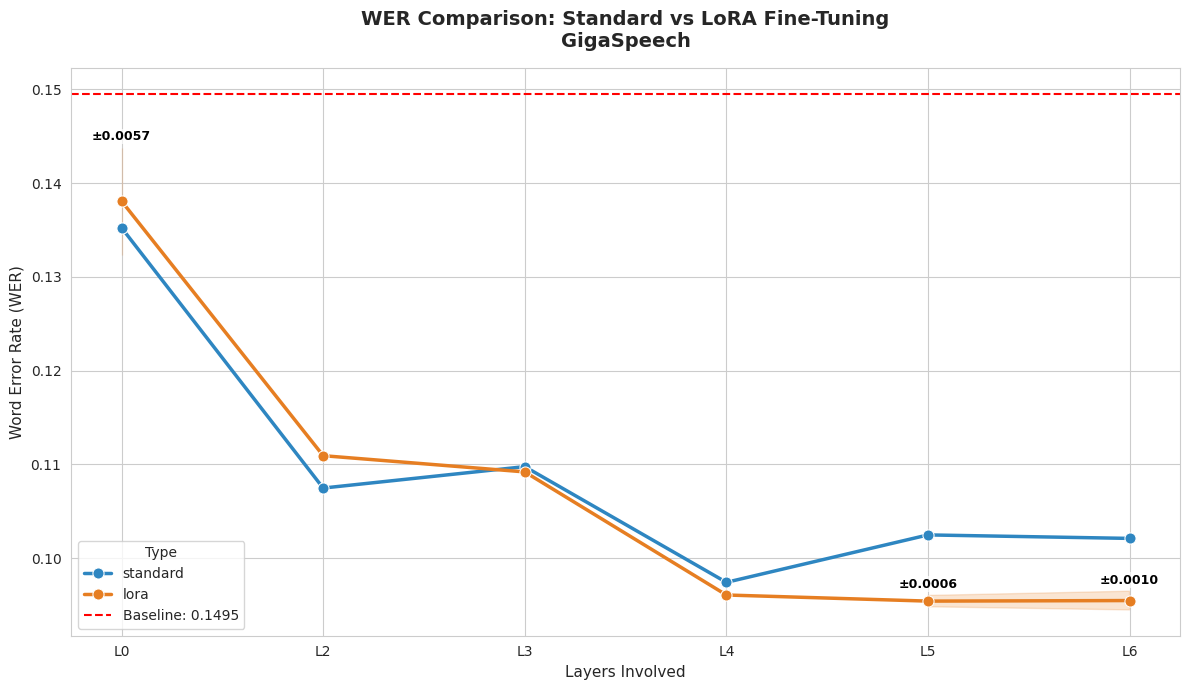

In [61]:
plot_wer_comparison(df_gigaspeech_results_total,
title="WER Comparison: Standard vs LoRA Fine-Tuning\nGigaSpeech")

In [56]:
spgispeech_results = load_results(spgi_paths)
spgispeech_results

[{'id': '000', 'wer': [0.11561548195786905], 'training_time': []},
 {'id': '0070', 'wer': [0.0419323206377262], 'training_time': [12655.0033]},
 {'id': '0071', 'wer': [0.04862135291784376], 'training_time': [13713.5315]},
 {'id': '0041', 'wer': [0.06716947756044377], 'training_time': [11496.0638]},
 {'id': '0040', 'wer': [0.05828067729211338], 'training_time': []},
 {'id': '0060', 'wer': [0.04461847306619457], 'training_time': [12020.5471]},
 {'id': '0061', 'wer': [0.05201749844577739], 'training_time': [12427.4731]},
 {'id': '002',
  'wer': [0.06878245085060307,
   0.06772493856102843,
   0.06898042284824735,
   0.06772056933247213,
   0.07013051197125275,
   0.06859800931322944],
  'training_time': []},
 {'id': '0080', 'wer': [0.04173933354649743], 'training_time': [12800.0314]},
 {'id': '0081', 'wer': [0.0487203389166659], 'training_time': [13704.1772]},
 {'id': '0050', 'wer': [0.05681155415851575], 'training_time': [11552.9383]},
 {'id': '0051', 'wer': [0.06934503314606702], 'train

In [57]:
spgispeech_2_df = pd.DataFrame(spgispeech_results)
spgispeech_2_df

,id,wer,training_time
0,000,[0.11561548195786905],[]
1,0070,[0.0419323206377262],[12655.0033]
2,0071,[0.04862135291784376],[13713.5315]
3,0041,[0.06716947756044377],[11496.0638]
4,0040,[0.05828067729211338],[]
5,0060,[0.04461847306619457],[12020.5471]
6,0061,[0.05201749844577739],[12427.4731]
7,002,"[0.06878245085060307, 0.06772493856102843, 0.0...",[]
8,0080,[0.04173933354649743],[12800.0314]
9,0081,[0.0487203389166659],[13704.1772]


In [58]:
spgispeech_2_df_total = pd.merge(spgispeech_2_df,experiment_types_df,on="id").sort_values(by="id").reset_index(drop=True)  
spgispeech_2_df_total

,id,wer,training_time,label,type
0,000,[0.11561548195786905],[],Baseline,baseline
1,001,[0.06831163596562129],[],L0,standard
2,002,"[0.06878245085060307, 0.06772493856102843, 0.0...",[],L0,lora
3,0040,[0.05828067729211338],[],L2,standard
4,0041,[0.06716947756044377],[11496.0638],L2,lora
5,0050,[0.05681155415851575],[11552.9383],L3,standard
6,0051,[0.06934503314606702],[11366.859],L3,lora
7,0060,[0.04461847306619457],[12020.5471],L4,standard
8,0061,[0.05201749844577739],[12427.4731],L4,lora
9,0070,[0.0419323206377262],[12655.0033],L5,standard


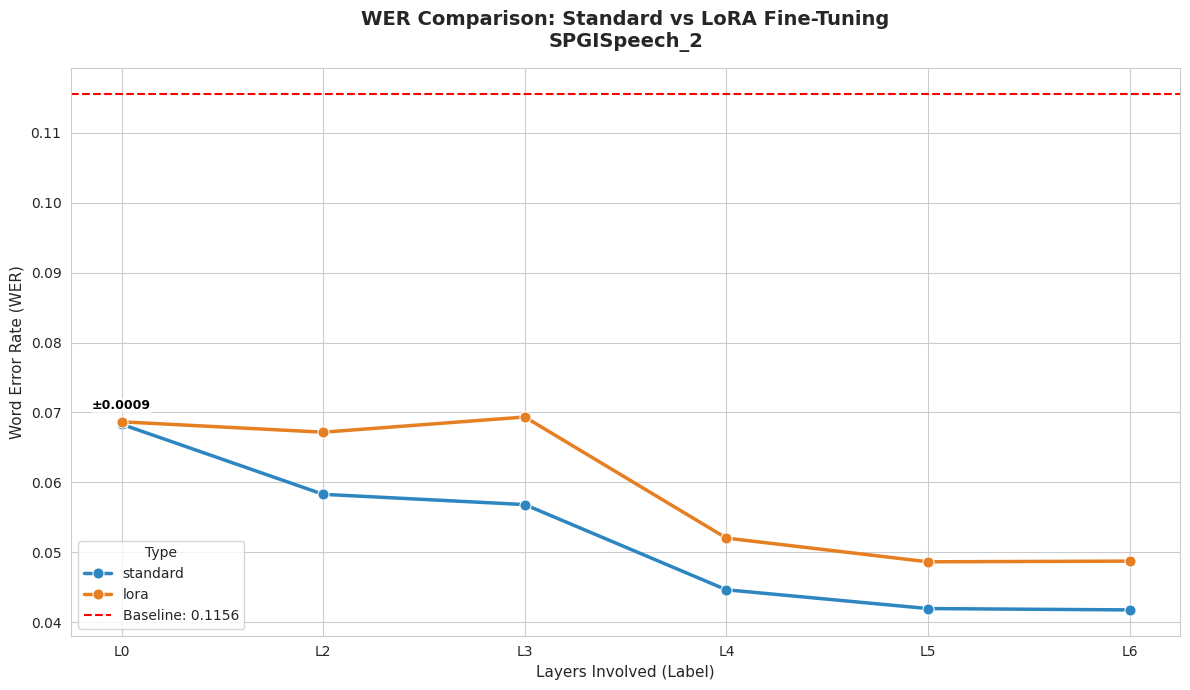

In [59]:
plot_wer_comparison(spgispeech_2_df_total,
title="WER Comparison: Standard vs LoRA Fine-Tuning\nSPGISpeech_2")